In [9]:
import sys
from pathlib import Path

parent_folder = Path.cwd().parent
if str(parent_folder) not in sys.path:
    sys.path.append(str(parent_folder))
    
import warnings
warnings.filterwarnings('ignore')

import scienceplots

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('science')
from analysis import Analysis
import nafflib

In [40]:
a = Analysis('data/basic/dir_sc')
Qx_a = a.get_tunes(a.x[a.survivor_mask], a.px[a.survivor_mask], 'x')
Qy_a = a.get_tunes(a.y[a.survivor_mask], a.py[a.survivor_mask], 'y')
b = Analysis('data/basic/ind_sc')
Qx_b = a.get_tunes(b.x[b.survivor_mask], b.px[b.survivor_mask], 'x')
Qy_b = a.get_tunes(b.y[b.survivor_mask], b.py[b.survivor_mask], 'y')

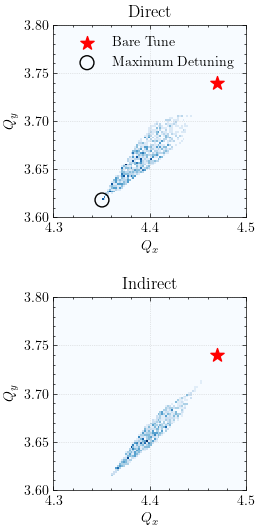

In [62]:
fig, axs = plt.subplots(2, figsize=(2.8, 5.6))
fig.subplots_adjust(wspace=0, hspace=0)
#plt.suptitle(f'    Tune Footprint', fontsize=16, fontweight='bold')#\nBare Tune: ({b.qx:.5f}, {b.qy:.5f})')
plt.tight_layout()
axs[0].hist2d(Qx_a, Qy_a, bins=100, cmap='Blues', range=[(4.3,4.5), (3.6,3.8)])
axs[0].scatter(a.qx, a.qy, marker='*', s=100, c='r', label='Bare Tune')
axs[0].scatter(min(Qx_a), min(Qy_a), marker='o', facecolors='none', s=100, edgecolors='k', label='Maximum Detuning')

axs[0].set_xlabel(r"$Q_x$")
axs[0].set_ylabel(r"$Q_y$")
axs[0].set_title(f'Direct')
axs[0].legend()
axs[0].set_aspect('equal')
axs[0].grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
axs[1].hist2d(Qx_b, Qy_b, bins=100, cmap='Blues', range=[(4.3,4.5), (3.6,3.8)])
axs[1].scatter(b.qx, b.qy, marker='*', s=100, c='r', label='Bare Tune')
axs[1].set_xlabel(r"$Q_x$")
axs[1].set_ylabel(r"$Q_y$")
axs[1].set_title(f'Indirect')
axs[1].set_aspect('equal')
axs[1].grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

fig.savefig('footprints.pdf')

In [6]:
from scipy.constants import e, epsilon_0

k_e = 1/(4*np.pi*epsilon_0)
_lambda = a.beam_intensity / a.length
K_sc = (2*k_e*e*_lambda/(a.beta*a.gamma**2*a.p0c))
R = a.length / (2*np.pi)

aa = K_sc*R**2/(2*a.qx*max(a.qx-Qx))
bb = K_sc*R**2/(2*a.qy*max(a.qy-Qy))

sigma_x = aa/np.sqrt(aa+bb)
sigma_y = bb/np.sqrt(aa+bb)
print(sigma_x)
print(sigma_y)

[0.01806308]
[0.02119627]


In [150]:
print(np.mean(a.sigma_x))
print(np.std(a.sigma_x))
print(np.mean(a.sigma_y))
print(np.std(a.sigma_y))

0.022505985938062224
0.00716653990514409
0.02150241474323619
0.004389711651127819


In [203]:
offsets = [0, 0.0001, 0.0004, 0.001, 0.004, 0.01, 0.04]#, 0.1]

qx_dir_list = []
qx_ind_list = []
qx_ultra_list = []
off = []
for dx in offsets:
    a = Analysis(f'data/sweep_offset/dir_{dx}')
    Qx = a.get_tunes(a.x[a.survivor_mask], a.px[a.survivor_mask], 'x')
    qx_dir_list.append(a.qx-Qx[0])
    
    a = Analysis(f'data/sweep_offset/ind_{dx}')
    Qx = a.get_tunes(a.x[a.survivor_mask], a.px[a.survivor_mask], 'x')
    qx_ind_list.append(a.qx-Qx[0])

    try:
        a = Analysis(f'data/sweep_offset/ultrawide_{dx}')
        Qx = a.get_tunes(a.x[a.survivor_mask], a.px[a.survivor_mask], 'x')
        qx_ultra_list.append(a.qx-Qx[0])
        off.append(dx)
    except:
        pass



Text(0, 0.5, '$\\Delta Q_x$')

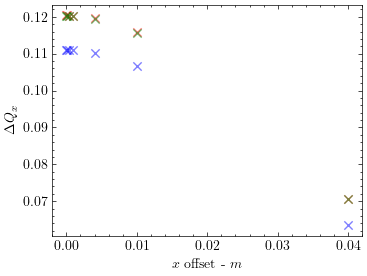

In [211]:
fig, ax = plt.subplots(figsize=(4,3))
ax.scatter(offsets, qx_dir_list, marker='x', c='r', label='Direct', alpha = 0.5)
ax.scatter(offsets, qx_ind_list, marker='x', c='b', label='Indirect', alpha = 0.5)
ax.scatter(off, qx_ultra_list, marker='x', c='g', label='Indirect', alpha = 0.5)

ax.set_xlabel(r'$x$ offset - $m$')
ax.set_ylabel(r'$\Delta Q_x$')
#ax.set_xscale('log')

In [186]:
int_list = [1e12, 2e12, 5e12, 1e13, 2e13, 5e13, 1e14]

qx_dir_list = []
qx_ind_list = []
qy_dir_list = []
qy_ind_list = []
loss_dir_list = []
loss_ind_list = []
x = []
for intensity in int_list:
    a = Analysis(f'data/sweep_intensity/ind_{intensity}')
    Qx = a.get_tunes(a.x[a.survivor_mask], a.px[a.survivor_mask], 'x')
    Qy = a.get_tunes(a.y[a.survivor_mask], a.py[a.survivor_mask], 'y')
    qx_ind_list.append(np.max(a.qx-Qx[0]))
    qy_ind_list.append(np.max(a.qy-Qy[0]))
    loss_dir_list.append(np.sum(a.survivor_mask)/a.n_particles)
    #plt.hist2d(Qx, Qy, bins=100, cmap='Blues')
    #plt.show()
    
    a = Analysis(f'data/sweep_intensity/dir_{intensity}')
    Qx = a.get_tunes(a.x[a.survivor_mask], a.px[a.survivor_mask], 'x')
    Qy = a.get_tunes(a.y[a.survivor_mask], a.py[a.survivor_mask], 'y')
    qx_dir_list.append(np.max(a.qx-Qx[0]))
    qy_dir_list.append(np.max(a.qy-Qy[0]))
    loss_ind_list.append(np.sum(a.survivor_mask)/a.n_particles)
    #plt.hist2d(Qx, Qy, bins=100, cmap='Blues')
    #plt.show()

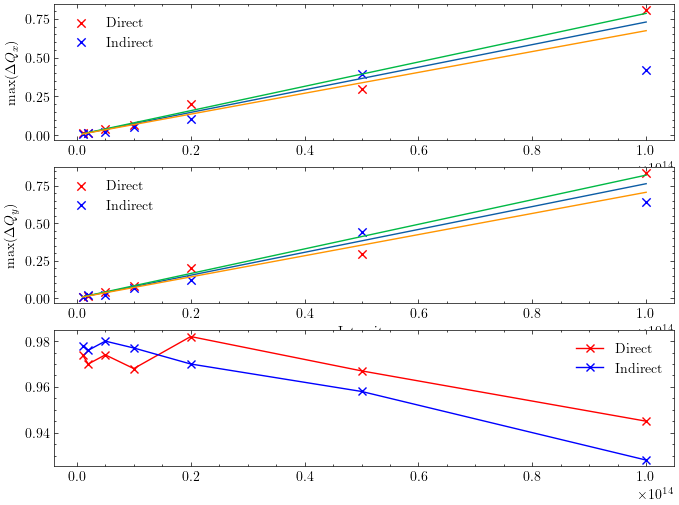

In [199]:
fig ,axs = plt.subplots(3, figsize=(8,6))
axs[0].scatter(int_list, qx_dir_list, marker='x', c='r', label='Direct')
axs[0].scatter(int_list, qx_ind_list, marker='x', c='b', label='Indirect')
axs[1].scatter(int_list, qy_dir_list, marker='x', c='r', label='Direct')
axs[1].scatter(int_list, qy_ind_list, marker='x', c='b', label='Indirect')

axs[0].set_ylabel(r'max($\Delta Q_x$)')
axs[1].set_ylabel(r'max($\Delta Q_y$)')
axs[1].set_xlabel(r'Intensity')

axs[0].legend()
axs[1].legend()

axs[0].plot(int_list, [m_a*i for i in int_list])
axs[0].plot(int_list, [(m_a+m_a_err)*i for i in int_list])
axs[0].plot(int_list, [(m_a-m_a_err)*i for i in int_list])
axs[1].plot(int_list, [m_b*i for i in int_list])
axs[1].plot(int_list, [(m_b+m_b_err)*i for i in int_list])
axs[1].plot(int_list, [(m_b-m_b_err)*i for i in int_list])

axs[2].plot(int_list, loss_dir_list, marker='x', c='r', label='Direct')
axs[2].plot(int_list, loss_ind_list, marker='x', c='b', label='Indirect')
axs[2].legend()

In [196]:
from scipy.optimize import curve_fit

def model(x, m):
    return m * x

popt, pcov = curve_fit(model, int_list, qx_dir_list, sigma=qx_dir_list, absolute_sigma=False)
m_a = popt[0]
m_a_err = np.sqrt(pcov[0, 0])
print(rf"Result: $m = {(m_a*1e14):.5f} \pm {(m_a_err*1e14):.5f}$")

popt, pcov = curve_fit(model, int_list, qy_dir_list, sigma=qy_dir_list, absolute_sigma=False)
m_b = popt[0]
m_b_err = np.sqrt(pcov[0, 0])
print(rf"Result: $m = {(m_b*1e14):.5f} \pm {(m_b_err*1e14):.5f}$")

Result: $m = 0.72982 \pm 0.05593$
Result: $m = 0.76391 \pm 0.05723$


In [197]:
ka = (k_e*e*R**2)/(a.length*a.beta*a.gamma**2*a.p0c*a.qx)
kb = (k_e*e*R**2)/(a.length*a.beta*a.gamma**2*a.p0c*a.qy)
aaa = 1/m_a * ka
bbb = 1/m_b * kb

aaa_err = ka*m_a_err/(m_a)**2
bbb_err = kb*m_b_err/(m_b)**2

sigma_x_err = (aaa_err-0.5*aaa*(aaa_err+bbb_err)/(aaa+bbb))/np.sqrt(aaa+bbb)
sigma_y_err = (bbb_err-0.5*bbb*(aaa_err+bbb_err)/(aaa+bbb))/np.sqrt(aaa+bbb)

sigma_x = aaa / np.sqrt(aaa+bbb)
sigma_y = bbb / np.sqrt(aaa+bbb)
print(f'{sigma_x} +- {sigma_x_err}')
print(f'{sigma_y} +- {sigma_y_err}')

[0.02329539] +- [0.00090336]
[0.02659996] +- [0.00098578]


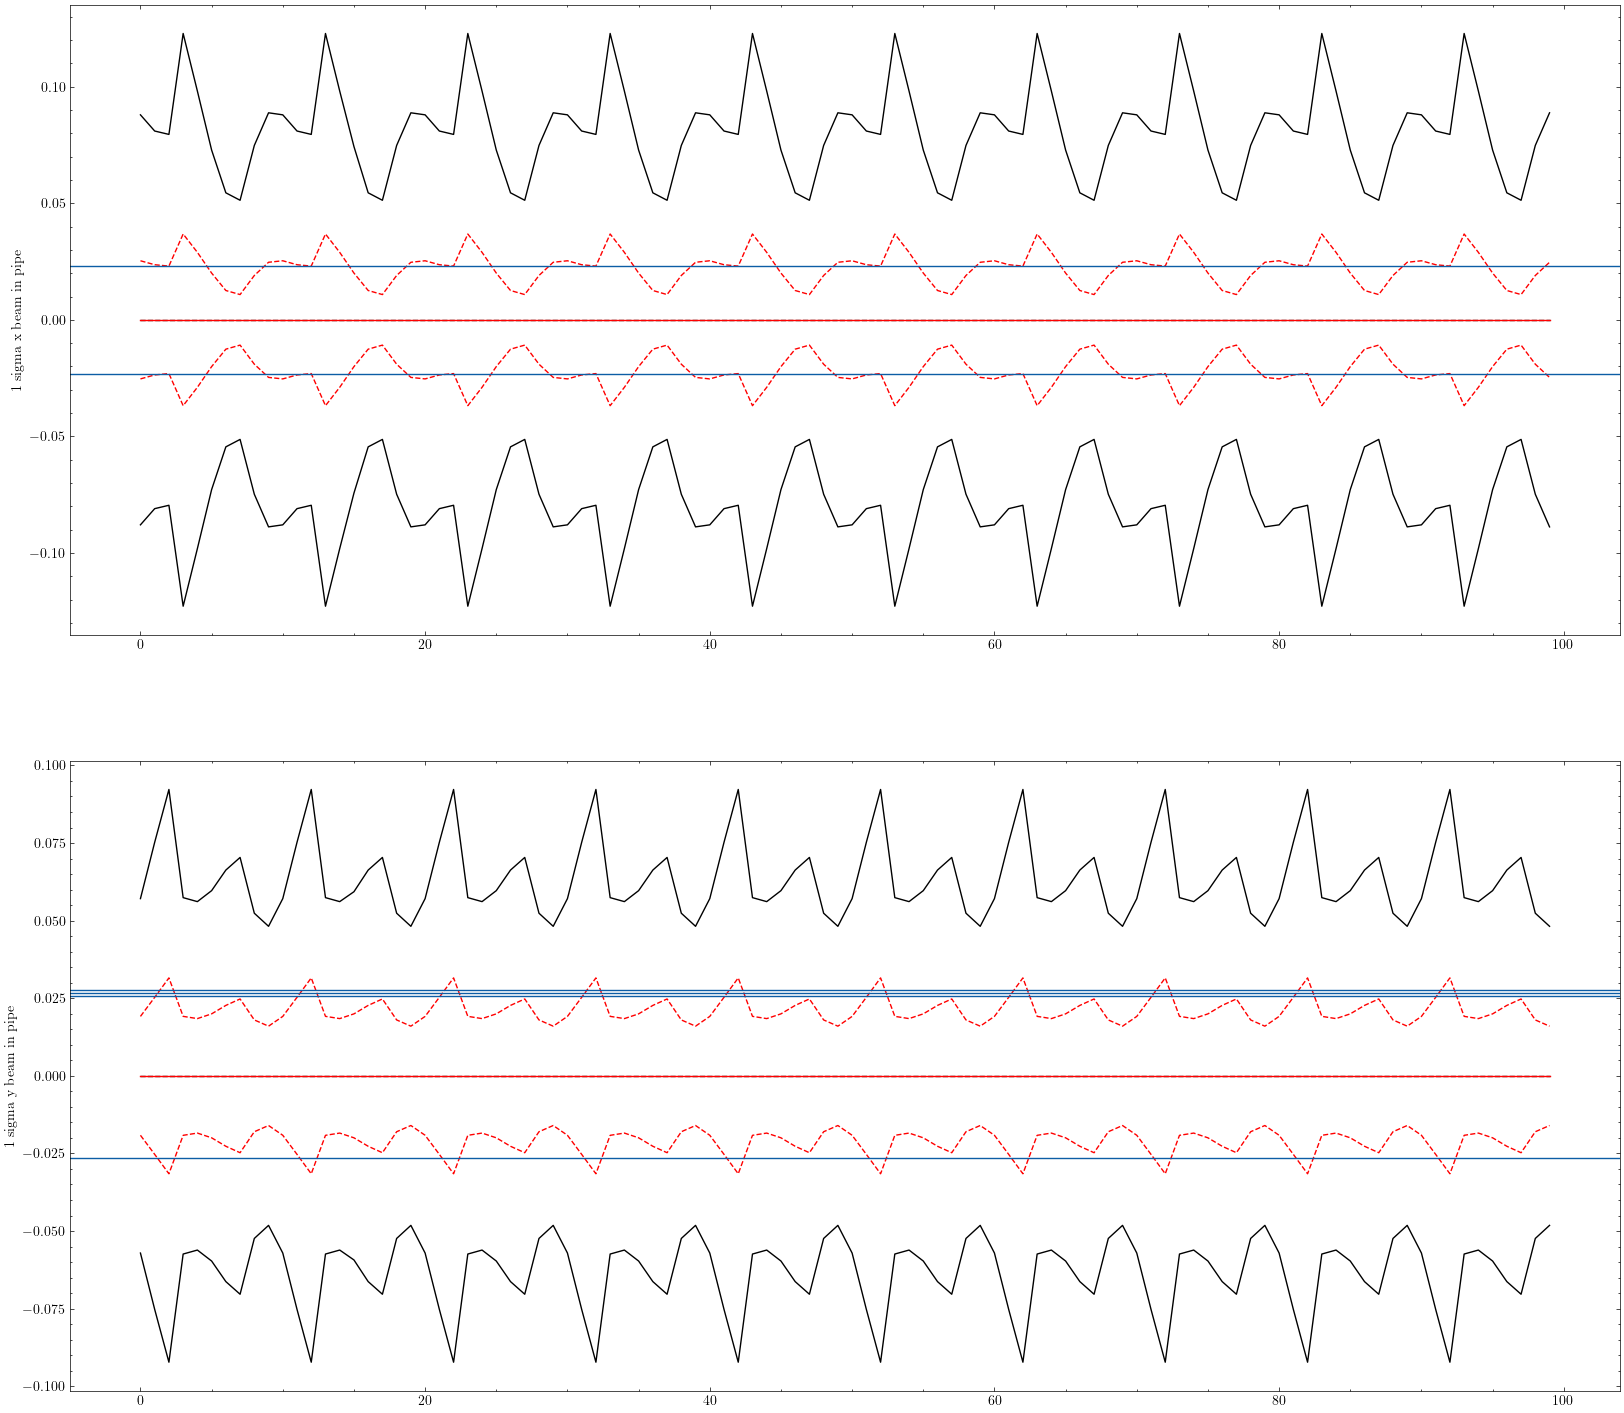

In [198]:
fig, axs=plt.subplots(2, figsize=(20,18))
axs[0].plot(np.zeros_like(a.x_pipe), c='k', ls='--')
axs[0].plot(a.x_pipe + a.x_length/2, c='k')
axs[0].plot(a.x_pipe - a.x_length/2, c='k')
axs[0].plot(a.x0, c='r')
axs[0].plot(a.x0 + a.sigma_x, c='r', ls='--')
axs[0].plot(a.x0 - a.sigma_x, c='r', ls='--')
axs[0].axhline(sigma_x)
axs[0].axhline(-sigma_x)

axs[1].plot(np.zeros_like(a.x_pipe), c='k', ls='--')
axs[1].plot(a.y_pipe + a.y_length/2, c='k')
axs[1].plot(a.y_pipe - a.y_length/2, c='k')
axs[1].plot(a.y0, c='r')
axs[1].plot(a.y0 + a.sigma_y, c='r', ls='--')
axs[1].plot(a.y0 - a.sigma_y, c='r', ls='--')
axs[1].axhline(sigma_y)
axs[1].axhline(sigma_y+sigma_y_err)
axs[1].axhline(sigma_y-sigma_y_err)
axs[1].axhline(-sigma_y)

axs[0].set_ylabel('1 sigma x beam in pipe')
axs[1].set_ylabel('1 sigma y beam in pipe')
plt.show()